In [8]:
import PyPlot as plt
using ImageIO, FileIO, ImageMagick, FFMPEG
using Statistics
ENV["JULIA_FFMPEG_PATH"] = "/opt/homebrew/bin/ffmpeg"
ENV["JULIA_FFPROBE_BINARY"] = replace("/opt/homebrew/bin/ffmpeg", "ffmpeg" => "ffprobe")

"/opt/homebrew/bin/ffprobe"

In [70]:
# Fujita STIV setup

import Images
import FFTW

function point_in_polygon(poly_xs::Vector{T}, poly_ys::Vector{T}, x::T, y::T) where T<: Real
    n_verts = length(poly_xs)
    j = n_verts
    c = false
    for i in 1:n_verts
        if (((poly_ys[i] <= y) && (y < poly_ys[j])) || ((poly_ys[j] <= y) && (y < poly_ys[i]))) && 
            (x < (poly_xs[j] - poly_xs[i]) * (y - poly_ys[i]) / (poly_ys[j] - poly_ys[i]) + poly_xs[i])
            c = !c
        end
        j = i
    end
    return c
end

# Changed these two functions to use bool matrix instead of values
function draw_polygon!(mask::Matrix{Bool}, poly_xs::Vector{Int}, poly_ys::Vector{Int})
    min_x, max_x = max(minimum(poly_xs), 1), min(maximum(poly_xs), size(mask, 2))
    min_y, max_y = max(minimum(poly_ys), 1), min(maximum(poly_ys), size(mask, 1))
    for y in min_y:max_y
        for x in min_x:max_x
            if point_in_polygon(poly_xs, poly_ys, x, y)
                mask[y, x] = true
            end
        end
    end
end

function polygons_to_mask(polygons::Array{Matrix{T}, 1} where T <: Real, max_x::Int, max_y::Int)::Matrix{Bool}
    poly_mask = zeros(Bool, max_y, max_x)  # Initialize a Bool matrix with all values set to false
    for p in polygons
        draw_polygon!(poly_mask, round.(Int, p[:, 1]), round.(Int, p[:, 2]))
    end
    return poly_mask
end

function centered_moving_average(vs, n)
    len = length(vs)
    vs_extended = vcat(vs[end-div(n,2)+1:end], vs, vs[1:div(n,2)])  # Wrap around
    return [sum(@view vs_extended[i:(i+n-1)]) / n for i in 1:len]
end

function max_centered_array_size(x::Int64, y::Int64, dims::Tuple{Int, Int})
    # Extract rows and cols from the dims tuple
    rows, cols = dims
    
    # Compute the max possible radius within bounds
    max_radius = min(y - 1, rows - y, x - 1, cols - x)
    
    # Compute the index ranges for rows and columns
    col_range = (x - max_radius):(x + max_radius)
    row_range = (y - max_radius):(y + max_radius)
    
    return row_range, col_range
end

function distribute_points_centered(n::Int, dims::Tuple{Int, Int})
    rows, cols = dims

    # Ensure the image has an odd number of rows
    if rows % 2 == 0
        rows -= 1  # Exclude the last row if rows is even
    end
    
    # Calculate the center row of the image
    center_row = div(rows, 2) + 1
    
    # Calculate the spacing between points along the center row
    # The leftmost point will be placed a fixed distance from the edge, and the rightmost point will be the same distance from the opposite edge.
    padding = center_row # Padding between points and from the edges
    spacing = div(cols - 2 * padding, n - 1)  # Adjusted spacing between points
    
    # Create an empty list to store the coordinates
    points = []
    
    # Place the leftmost and rightmost points with equal distance from the edges
    leftmost_col = padding
    rightmost_col = cols - padding
    
    # Add the leftmost and rightmost points
    push!(points, (center_row, leftmost_col))
    
    # Distribute the remaining points evenly between the leftmost and rightmost points
    for i in 1:n-2
        col = leftmost_col + (spacing * i)
        push!(points, (center_row, col))
    end
    
    push!(points, (center_row, rightmost_col))
    
    return points
end

function calculate_x_range(slope, x_center, y_center, image_height)
    # Calculate x-values for the top and bottom of the image
    y_top = 1
    y_bottom = image_height

    # Calculate the corresponding x-values for the top and bottom rows
    x_top = (y_top - y_center) / slope + x_center
    x_bottom = (y_bottom - y_center) / slope + x_center

    # Return the range of x-values covered by the line
    x_min = min(x_top, x_bottom)
    x_max = max(x_top, x_bottom)

    return Int(round(x_min)), Int(round(x_max))
end

function find_peaks_and_midpoints(
    img::AbstractMatrix,
    n_peaks::Int,
    m_midpoints::Int,
    buffer::Int
)
    height, width = size(img)
    row_idx = ceil(Int, height / 2)
    row_vals = img[row_idx, :]

    half_height = div(height, 2)

    # Allowed columns (exclude edges within half height)
    allowed_cols = collect((half_height+1):(width - half_height))
    allowed_vals = row_vals[allowed_cols]

    # --- Find n highest peaks ---
    # Sort by descending intensity
    sorted_peak_indices = sortperm(allowed_vals, rev=true)
    selected_peaks = Int[]

    for idx in sorted_peak_indices
        col = allowed_cols[idx]
        # Ensure buffering between peaks
        if all(abs(col - c) > buffer for c in selected_peaks)
            push!(selected_peaks, col)
            if length(selected_peaks) == n_peaks
                break
            end
        end
    end

    # --- Find m mid-intensity points ---
    # Intensity midpoint
    min_val, max_val = extrema(allowed_vals)
    mid_val = (max_val + min_val) / 2

    # Filter out cols too close to peaks
    non_peak_cols = [c for c in allowed_cols if all(abs(c - p) > buffer for p in selected_peaks)]
    non_peak_vals = row_vals[non_peak_cols]

    diffs = abs.(non_peak_vals .- mid_val)
    sorted_mid_indices = sortperm(diffs)
    selected_mids = Int[]

    for idx in sorted_mid_indices
        col = non_peak_cols[idx]
        # Ensure buffering between midpoints themselves
        if all(abs(col - c) > buffer for c in selected_mids)
            push!(selected_mids, col)
            if length(selected_mids) == m_midpoints
                break
            end
        end
    end

    # Combine and sort results as (row, col) tuples
    peaks = [(row_idx, c) for c in sort(selected_peaks)]
    mids = [(row_idx, c) for c in sort(selected_mids)]

    return peaks, mids
end

"""
    find_strong_local_maxima(signal; radius=1)

Find indices of local maxima in `signal` such that each candidate
is strictly greater than all values within ±radius.
"""
function find_strong_local_maxima(signal::AbstractVector; radius::Int=1)
    n = length(signal)
    peaks = Int[]
    for i in (1+radius):(n-radius)
        neighborhood = signal[(i-radius):(i+radius)]
        if signal[i] == maximum(neighborhood) && count(==(signal[i]), neighborhood) == 1
            push!(peaks, i)
        end
    end
    return peaks
end

function find_isolated_peak(signal::AbstractVector, zero_idx::Int, global_idx::Int;
                            radius::Int=1, buffer::Int=0)
    lo, hi = minmax(zero_idx, global_idx)
    lo = max(lo, 1)                   # ensure ≥ 1
    hi = min(hi, length(signal))      # ensure ≤ signal length

    # Step 1: local maxima in restricted range
    candidates = find_strong_local_maxima(signal; radius=radius)

    # Exclude near-zero_idx (within buffer) and outside lo/hi
    candidates = filter(i -> lo < i < hi && abs(i - zero_idx) > buffer, candidates)

    if isempty(candidates)
        return nothing
    end

    best_peak, best_score = nothing, -Inf

    for i in candidates
        # Left span until beaten
        left_span = 0
        for j in (i-1):-1:lo
            if signal[j] > signal[i]
                break
            end
            left_span += 1
        end

        # Right span until beaten
        right_span = 0
        for j in (i+1):hi
            if signal[j] > signal[i]
                break
            end
            right_span += 1
        end

        isolation_score = (left_span + right_span) / 2

        if isolation_score > best_score
            best_score = isolation_score
            best_peak = i
        end
    end

    return best_peak, signal[best_peak], best_score
end

function find_isolated_peak(signal::AbstractVector, zero_idx::Int, global_idx::Int;
                            radius::Int=1, buffer::Int=0)
    lo, hi = minmax(zero_idx, global_idx)
    lo = max(lo, 1)                   # ensure ≥ 1
    hi = min(hi, length(signal))      # ensure ≤ signal length

    # Step 1: local maxima in restricted range
    candidates = find_strong_local_maxima(signal; radius=radius)

    # Exclude near-zero_idx (within buffer) and outside lo/hi
    candidates = filter(i -> (lo < i < hi) && abs(i - zero_idx) > buffer, candidates)

    if isempty(candidates)
        return nothing
    end

    # Find candidate closest to the wave peak (global_idx)
    best_peak_idx = candidates[argmin(abs.(candidates .- global_idx))]

    # Compute isolation score for reference
    left_span = 0
    for j in (best_peak_idx-1):-1:lo
        if signal[j] > signal[best_peak_idx]
            break
        end
        left_span += 1
    end

    right_span = 0
    for j in (best_peak_idx+1):hi
        if signal[j] > signal[best_peak_idx]
            break
        end
        right_span += 1
    end

    isolation_score = (left_span + right_span) / 2

    return best_peak_idx, signal[best_peak_idx], isolation_score
end

function align_zero_min_expand(ax_ref, ax_target; pad_frac=0.02)
    """
    Align y=0 on ax_target to ax_ref, expanding ax_target's span
    by the minimal amount needed (plus pad_frac) so no data is cut off.
    """
    # 1) Reference zero relative position
    y0r, y1r = ax_ref.get_ylim()
    rel0 = (0 - y0r) / (y1r - y0r)

    # 2) Target data extents
    dmin, dmax = ax_target.dataLim.ymin, ax_target.dataLim.ymax
    pad = pad_frac * (dmax - dmin)

    # 3) Compute required spans so data + pad fit above and below zero:
    #    below zero we need b ≤ dmin - pad  where b = -rel0*s
    #    above zero we need b + s ≥ dmax + pad  ⇒ -rel0*s + s ≥ dmax + pad
    # Solve each:
    s_req1 = (dmax + pad) / (1 - rel0)
    s_req2 = -(dmin - pad) / rel0

    # 4) Take the largest requirement, or keep original if it's already big enough
    y0t, y1t = ax_target.get_ylim()
    orig_span = y1t - y0t
    new_span = max(orig_span, s_req1, s_req2)

    # 5) Compute new bottom b so that zero is at rel0 * new_span
    new_y0 = -rel0 * new_span
    new_y1 = new_y0 + new_span

    ax_target.set_ylim(new_y0, new_y1)
    ax_ref.axhline(0, color="gray", linewidth=1)
end

align_zero_min_expand (generic function with 1 method)

In [50]:
# Convert RGB{T} image to Float32 H×W×3 array
# Convert RGB{N0f16} image to Float32 H×W×3 array
function rgb_to_gray(img)
    R = Float32.(getfield.(img, :r))
    G = Float32.(getfield.(img, :g))
    B = Float32.(getfield.(img, :b))
    RGB = cat(R, G, B; dims=3)
    return dropdims(mean(RGB, dims=3), dims=3)
end

rgb_to_gray (generic function with 1 method)

In [ ]:
using VideoIO
using Colors

# Parameters
folder = "/Users/evanheberlein/Library/CloudStorage/Box-Box/GoPro/LabTest2/"
Nframes = 80  # number of images to load

# Get sorted list of DPX files
dpx_files = sort(filter(f -> endswith(f, ".dpx"), readdir(folder; join=true)))
dpx_files = dpx_files[1:min(Nframes, length(dpx_files))]

# Preload first frame to get size
reader = VideoIO.openvideo(dpx_files[1])
first_frame = read(reader)
close(reader)

height, width = size(first_frame)
# Preallocate grayscale array: H x W x n
frames_gray = []

# Loop through files
for (i, file) in enumerate(dpx_files)
    reader = VideoIO.openvideo(file)
    frame = read(reader)   # 2D Array of RGB{N6f10}
    close(reader)

    # Convert to grayscale
    frame_gray = rgb_to_gray(frame)
    frame_gray .-= mean(frame_gray)
    push!(frames_gray, frame_gray)   # still 2D, Float32 0-1
end

size(frames_gray)  # => (height, width, n)



(80,)

In [89]:
folder = "/Users/evanheberlein/Library/CloudStorage/Box-Box/GoPro/LabTest2/"
Nframes = 80  # number of images to load

# Get sorted list of DPX files
dpx_files = sort(filter(f -> endswith(f, ".dpx"), readdir(folder; join=true)))
dpx_files = dpx_files[1:min(Nframes, length(dpx_files))]

# Preload first frame to get size
reader = VideoIO.openvideo(dpx_files[1])
first_frame = read(reader)

float32(minimum(channelview(first_frame)))

0.0f0

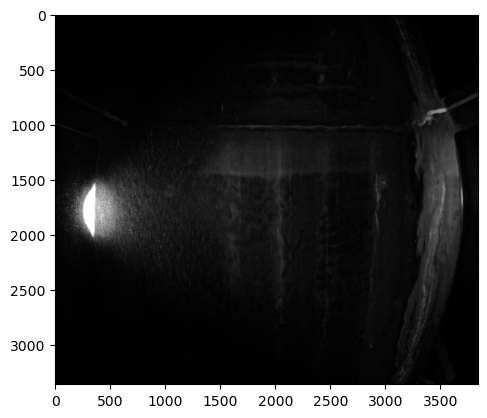

In [63]:
plt.figure()
plt.imshow(frames_gray[1], cmap="gray")  # display first grayscale frame
plt.gcf()

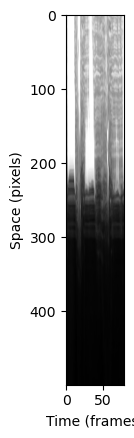

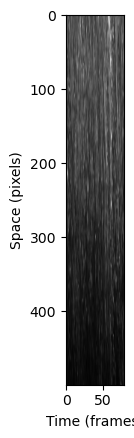

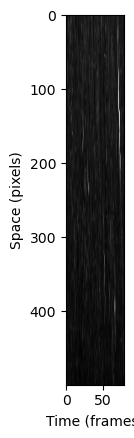

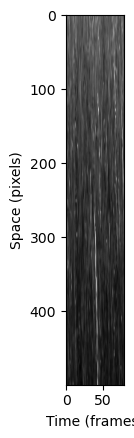

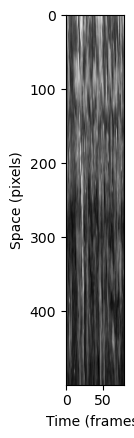

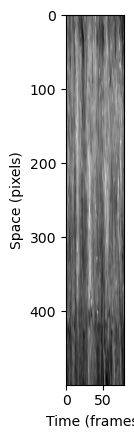

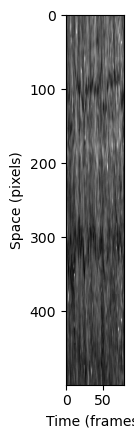

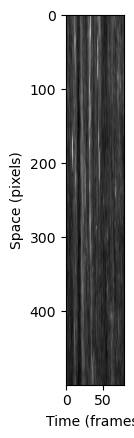

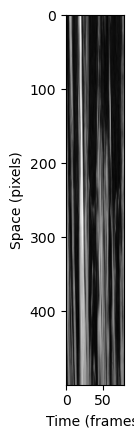

In [101]:
plt.pygui(false)        
plt.close("all")                   
 
STIV_size = size(frames_gray)[1] -1
center = ceil(STIV_size / 2)
radius = center-1
θ_c = range(1, stop = 360, length = 360)
xc = radius * cosd.(θ_c) .+ center
yc = radius * sind.(θ_c) .+ center
# circ_mask = polygons_to_mask([hcat(xc, yc)], center+radius, center+radius)
# circ_nan = ones(Float64, size(circ_mask))
# circ_nan[.!circ_mask] .= NaN

STIV_start_row = 1800
# STIV_end_row = STIV_start_row + STIV_size - 1
STIV_size_2_test = 500
STIV_end_row = STIV_start_row + STIV_size_2_test - 1
img_width = size(GoPro_stack)[2]
STIV_inds = round.(Int, range(375, 3300, length = 10))

for (STIV_ind, col) in enumerate(STIV_inds)

    STIV_img = zeros(STIV_size_2_test, STIV_size)
    for time_ind in 1:Nframes-1
        STIV_img[:, time_ind] = frames_gray[time_ind][STIV_start_row:STIV_end_row, col]
    end

    # Rxy = FFTW.ifft(abs.(FFTW.fft(STIV_img)).^2) ./ length(STIV_img)
    # Rxy = FFTW.fftshift(abs.(Rxy)) # Seems important - shifts zero-frequency component to center of spectrum
    # θ = zeros(Float64, STIV_size, STIV_size)
    # ρ = zeros(Float64, STIV_size, STIV_size)
    # Tx = zeros(Float64, STIV_size, STIV_size)
    # Ty = zeros(Float64, STIV_size, STIV_size)
    M = 15  # "coefficient of intensification"

    # for i in 1:Nframes
    #     for j in 1:Nframes
    #         if circ_mask[i, j]
    #             Tx[i,j] = center - j
    #             Ty[i,j] = center - i
    #             θ[i,j] = atand(Ty[i,j] / Tx[i, j]) # -90 to 90
    #             ρ[i,j] = M * log(sqrt(Tx[i,j]^2 + Ty[i,j]^2)) 
    #         end
    #     end
    # end
    # Apply the circular mask to Rxy
    # Rxy_pol_norm = Rxy .* circ_nan ./ Rxy[center, center]
    # ρ = ρ .* circ_nan
    # θ = θ .* circ_nan

    fig = plt.figure()
    plt.imshow(STIV_img; cmap="gray")#, aspect="equal")
    plt.axis("image")          # ← this forces the drawing to be square
    plt.xlabel("Time (frames)")
    plt.ylabel("Space (pixels)")
    # plt.colorbar()
    plt.display(fig)
end

In [25]:
import Pkg; Pkg.add("VideoIO")

   Resolving package versions...
   Installed VideoIO ─ v1.4.0
    Updating `~/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_22_jl/Project.toml`
  [d6d074c3] + VideoIO v1.4.0
    Updating `~/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_22_jl/Manifest.toml`
  [c27321d9] + Glob v1.3.1
  [d6d074c3] + VideoIO v1.4.0
Precompiling project...
   1781.5 ms  ✓ Glob
   6662.7 ms  ✓ VideoIO
  2 dependencies successfully precompiled in 11 seconds. 556 already precompiled.
  1 dependency had output during precompilation:
┌ VideoIO
│  WARNING: using libffmpeg.##meta#59 in module VideoIO conflicts with an existing identifier.
└  


In [62]:
# Import lab images

GoPro_path = "/Users/evanheberlein/Library/CloudStorage/Box-Box/GoPro/LabTest1/"

GoPro_dng_list = filter(f -> endswith(lowercase(f), ".dng"), readdir(GoPro_path; join=true))

# load first image to get size
first_img = FileIO.load(GoPro_dng_list[1])
H, W = size(first_img)    # assume grayscale; add 3rd dimension if RGB

# allocate a 3D array (H × W × N)
N = length(GoPro_dng_list)
GoPro_stack = Array{eltype(first_img)}(undef, H, W, N)

# load all images
for (i, f) in enumerate(GoPro_dng_list)
    GoPro_stack[:, :, i] = FileIO.load(f)
end

import ImageCore

plt.figure()
plt.imshow(Float32.(permutedims(ImageCore.channelview(GoPro_stack[:, :, 1]), (2,3,1))))
plt.gcf()

In [ ]:
plt.pygui(true)
plt.close("all")

plt.ion()                              # turn on interactive mode

fig, ax = plt.subplots()
im = ax.imshow(rgb_to_array(GoPro_stack[:,:,1]))
ax.axis("off")

plt.show()                              # make sure the window appears
fig = plt.gcf()                          # get current figure

for i in 1:size(GoPro_stack, 3)
    im.set_data(rgb_to_array(GoPro_stack[:, :, i]))
    ax.set_title("Frame $i")
    fig.canvas.draw()                   # redraw updated data
    plt.pause(0.01)                     # short pause to update
end

2025-12-05 12:32:08.431 julia[1168:11056] +[IMKClient subclass]: chose IMKClient_Modern
2025-12-05 12:32:08.431 julia[1168:11056] +[IMKInputSession subclass]: chose IMKInputSession_Modern


UndefVarError: UndefVarError: `rgb_to_array` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

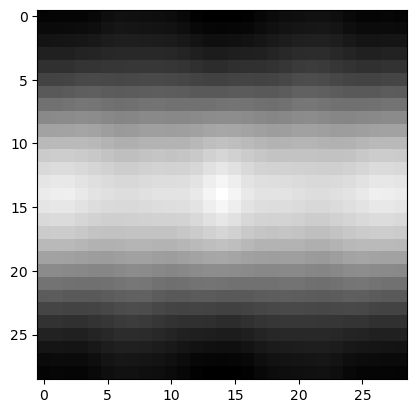

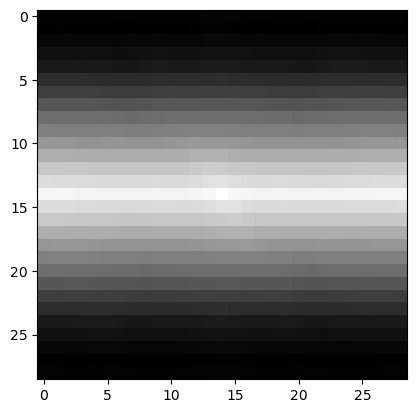

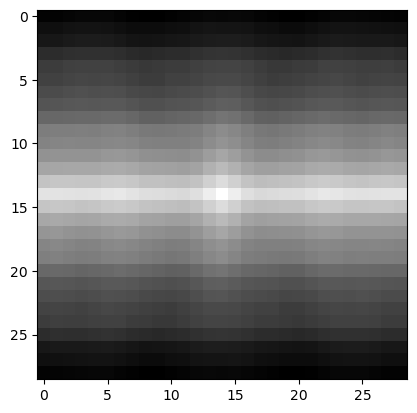

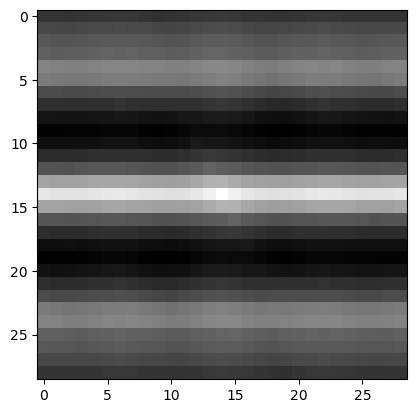

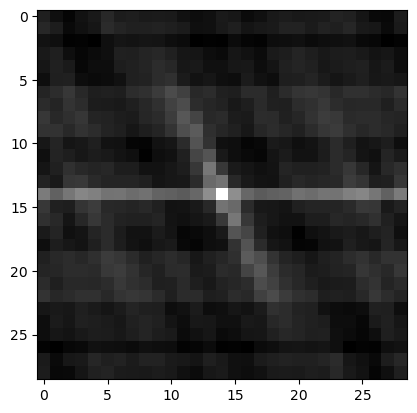

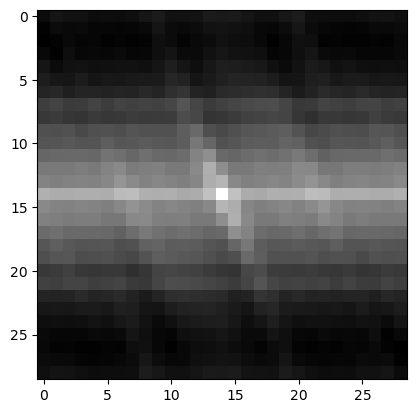

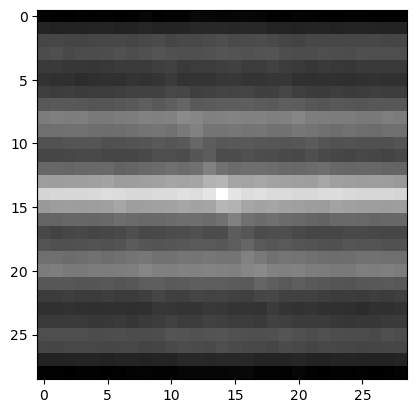

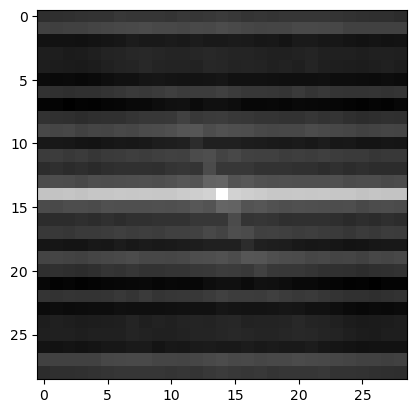

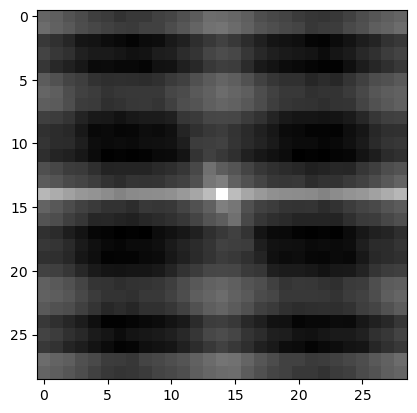

In [124]:
plt.pygui(false)                           

# Convert all frames to grayscale and stack
Nframes = size(GoPro_stack, 3)
H, W = size(GoPro_stack)[1:2]
GoPro_stack_gray = Array{Float32}(undef, H, W, Nframes)
for i in 1:Nframes
    GoPro_stack_gray[:, :, i] = rgb_to_gray(GoPro_stack[:, :, i]) .- mean(rgb_to_gray(GoPro_stack[:, :, i]))
end
STIV_size = size(GoPro_stack_gray)[3]-1
center = ceil(STIV_size / 2)
radius = center-1
θ_c = range(1, stop = 360, length = 360)
xc = radius * cosd.(θ_c) .+ center
yc = radius * sind.(θ_c) .+ center
# circ_mask = polygons_to_mask([hcat(xc, yc)], center+radius, center+radius)
# circ_nan = ones(Float64, size(circ_mask))
# circ_nan[.!circ_mask] .= NaN

STIV_start_row = 50
STIV_end_row = STIV_start_row + STIV_size - 1
img_width = size(GoPro_stack)[2]
STIV_inds = round.(Int, range(50, 185, length = 10))

for (STIV_ind, col) in enumerate(STIV_inds)

    STIV_img = zeros(STIV_size, STIV_size)
    for time_ind in 1:Nframes-1
        STIV_img[:, time_ind] = GoPro_stack_gray[STIV_start_row:STIV_end_row, col, time_ind]
    end

    Rxy = FFTW.ifft(abs.(FFTW.fft(STIV_img)).^2) ./ length(STIV_img)
    Rxy = FFTW.fftshift(abs.(Rxy)) # Seems important - shifts zero-frequency component to center of spectrum
    θ = zeros(Float64, STIV_size, STIV_size)
    ρ = zeros(Float64, STIV_size, STIV_size)
    Tx = zeros(Float64, STIV_size, STIV_size)
    Ty = zeros(Float64, STIV_size, STIV_size)
    M = 15  # "coefficient of intensification"

    # for i in 1:Nframes
    #     for j in 1:Nframes
    #         if circ_mask[i, j]
    #             Tx[i,j] = center - j
    #             Ty[i,j] = center - i
    #             θ[i,j] = atand(Ty[i,j] / Tx[i, j]) # -90 to 90
    #             ρ[i,j] = M * log(sqrt(Tx[i,j]^2 + Ty[i,j]^2)) 
    #         end
    #     end
    # end
    # Apply the circular mask to Rxy
    # Rxy_pol_norm = Rxy .* circ_nan ./ Rxy[center, center]
    # ρ = ρ .* circ_nan
    # θ = θ .* circ_nan

    fig = plt.figure()
    plt.imshow(Rxy; cmap="gray", aspect="equal")
    plt.display(fig)
end

In [122]:
center+radius

29.0